# Practical Session 1: Linear Programming and Maximum Flow

This notebook is a fully documented model solution for the current practical script.
It first reviews the basic `cvxpy` workflow with a tiny linear program and then
formulates the maximum-flow problem as a linear program.


In [4]:
# Import NumPy for array computations.
import numpy as np
# Import pandas to present optimization results as readable tables.
import pandas as pd
# Import cvxpy to formulate and solve convex optimization problems.
import cvxpy as cp
# Import Matplotlib for the parameter-sweep plot.
import matplotlib.pyplot as plt
# Import simple graph utilities for the greedy augmenting-path baseline.
from collections import defaultdict, deque

# Print arrays compactly so notebook output stays readable.
np.set_printoptions(precision=4, suppress=True)

# Prefer CLARABEL when available because it is fast and stable for these small LPs.
SOLVER = "CLARABEL" if "CLARABEL" in cp.installed_solvers() else "SCS"
print("Using solver:", SOLVER)


Using solver: CLARABEL


## Task 1: Small introductory linear program

The next cell demonstrates the standard optimization workflow: define variables,
objective, constraints, solve the model, and inspect the result.


In [5]:
# Create two nonnegative decision variables.
# TODO: Create two nonnegative decision variables.
x = cp.Variable(2, nonneg=True)

# Build a tiny LP with a linear objective and two linear inequalities.
introductory_problem = cp.Problem(
    cp.Maximize(3 * x[0] + 2 * x[1]),
    [
        x[0] + x[1] <= 4,
        2 * x[0] + x[1] <= 5,
    ],
)
# Solve the problem with the chosen solver.
# TODO: Solve the introductory linear program with the chosen solver.
introductory_problem.solve()

# Report the solver status to confirm that an optimum was found.
print("Introductory LP status:", introductory_problem.status)
# Print the optimal objective value of the small example.
print("Optimal objective value:", introductory_problem.value)
# Print the optimal decision vector.
print("Optimal decision vector:", x.value)


Introductory LP status: optimal
Optimal objective value: 8.999999982178412
Optimal decision vector: [1. 3.]


## Tasks 2 and 3: Maximum-flow model and solution inspection

We now introduce one flow variable per directed edge, maximize the total flow leaving
the source, enforce edge capacities, and enforce flow conservation at all internal
nodes.


In [8]:
# Store the graph nodes explicitly so the conservation loop is easy to read.
nodes = [1, 2, 3, 4, 5, 6]
# Define source and sink according to the practical script.
source, sink = 1, 6
# Store capacities in a dictionary keyed by directed edges.
capacities = {
    (1, 2): 7,
    (1, 3): 6,
    (2, 3): 2,
    (2, 4): 5,
    (2, 5): 3,
    (3, 5): 6,
    (5, 4): 3,
    (4, 6): 6,
    (5, 6): 8,
}
# Freeze the edge order once so all later tables use the same layout.
edges = list(capacities)


def solve_max_flow(capacity_dict):
    # Create one nonnegative optimization variable for each directed edge.
# TODO: Create one nonnegative flow variable for every directed edge.
    flow = {
        edge: cp.Variable(nonneg=True)
        for edge in edges
    }
    # Add one capacity constraint for each edge.
    constraints = [flow[edge] <= capacity_dict[edge] for edge in edges]

    # Enforce conservation only at internal nodes.
    for node in nodes:
        # Sum all incoming flows of the current node.
        inflow_terms = [flow[(i, j)] for (i, j) in edges if j == node]
        inflow = cp.sum(inflow_terms) if inflow_terms else 0
        # Sum all outgoing flows of the current node.
        outflow_terms = [flow[(i, j)] for (i, j) in edges if i == node]
        outflow = cp.sum(outflow_terms) if outflow_terms else 0
        # Skip source and sink because their net flow is not forced to zero.
        if node in (source, sink):
            continue
        # Add the balance equation inflow = outflow.
        # TODO: Add the flow-conservation constraint for internal nodes.
        constraints.append(inflow == outflow)

    # Maximize the total flow that leaves the source node.
    source_outflow = cp.sum([flow[(i, j)] for (i, j) in edges if i == source])
    problem = cp.Problem(cp.Maximize(source_outflow), constraints)
    # Solve the LP and keep the numerical flow values for later checks.
    problem.solve(solver=SOLVER)

    # Convert cvxpy scalars to plain Python floats for tables and reports.
    flow_values = {edge: float(flow[edge].value) for edge in edges}
    return {"status": problem.status, "value": float(problem.value), "flow": flow_values}


# Solve the base maximum-flow instance from the practical script.
max_flow_result = solve_max_flow(capacities)

# Build a readable table with capacities and optimal flows.
flow_df = pd.DataFrame(
    {
        "capacity": pd.Series(capacities),
        "flow": pd.Series(max_flow_result["flow"]),
    }
)
# Compute remaining capacity to see which edges are bottlenecks.
flow_df["residual_capacity"] = flow_df["capacity"] - flow_df["flow"]
# Mark saturated edges up to numerical tolerance.
flow_df["saturated"] = np.isclose(flow_df["flow"], flow_df["capacity"], atol=1e-6)


def node_balance_report(flow_values):
    # Collect one row per node to verify the conservation equations numerically.
    rows = []
    for node in nodes:
        # Sum all incoming flow values for the current node.
        inflow = sum(value for (i, j), value in flow_values.items() if j == node)
        # Sum all outgoing flow values for the current node.
        outflow = sum(value for (i, j), value in flow_values.items() if i == node)
        rows.append(
            {
                "node": node,
                "inflow": inflow,
                "outflow": outflow,
                "balance_in_minus_out": inflow - outflow,
            }
        )
    return pd.DataFrame(rows)


# Evaluate node balances for the computed optimal flow.
balance_df = node_balance_report(max_flow_result["flow"])

# Print the global optimization status and objective value.
print("Maximum-flow problem status:", max_flow_result["status"])
print("Optimal maximum flow value:", max_flow_result["value"])
# Show the edge table so students can inspect each flow variable.
display(flow_df)
# Show the node balances to confirm feasibility.
display(balance_df)

# Focus the formal conservation check on internal nodes only.
internal_nodes = [node for node in nodes if node not in (source, sink)]
conservation_ok = all(
    abs(balance_df.loc[balance_df["node"] == node, "balance_in_minus_out"].iloc[0]) <= 1e-6
    for node in internal_nodes
)
print("Flow conservation satisfied at all internal nodes:", conservation_ok)


Maximum-flow problem status: optimal
Optimal maximum flow value: 12.999999999615747


capacity          flow  residual_capacity  saturated
1 2         7  7.000000e+00       1.112257e-10       True
  3         6  6.000000e+00       2.730269e-10       True
2 3         2  2.642785e-10       2.000000e+00      False
  4         5  4.373305e+00       6.266948e-01      False
  5         3  2.626695e+00       3.733052e-01      False
3 5         6  6.000000e+00       8.748557e-12       True
5 4         3  1.220468e+00       1.779532e+00      False
4 6         6  5.593774e+00       4.062263e-01      False
5 6         8  7.406226e+00       5.937737e-01      False

,node,inflow,outflow,balance_in_minus_out
0,1,0.000000,13.000000,-1.300000e+01
1,2,7.000000,7.000000,8.881784e-16
2,3,6.000000,6.000000,0.000000e+00
3,4,5.593774,5.593774,-8.881784e-16
4,5,8.626695,8.626695,0.000000e+00
5,6,13.000000,0.000000,1.300000e+01


Flow conservation satisfied at all internal nodes: True


## Task 4: Capacity sensitivity by parameter sweep

The practical asks us to vary one bottleneck capacity without rewriting the full model.
We therefore reuse the helper function above and only change one dictionary entry.


,"capacity_of_(4,6)",optimal_max_flow
0,1,9.0
1,2,10.0
2,3,11.0
3,4,12.0
4,5,13.0
5,6,13.0
6,7,13.0
7,8,13.0
8,9,13.0
9,10,13.0


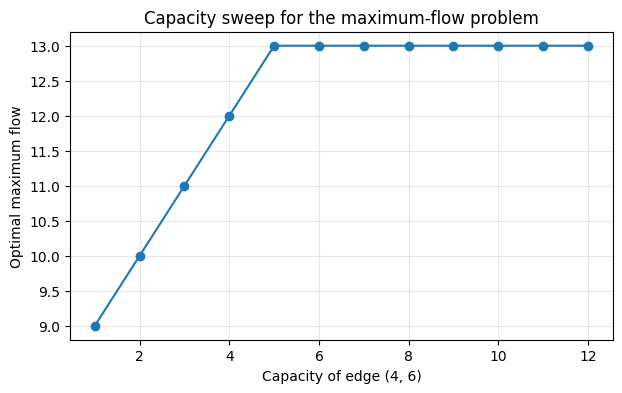

In [ ]:
# Select the edge whose capacity will be varied.
varied_edge = (4, 6)
# Test an integer range of capacities, as requested in the script.
tested_capacities = np.arange(1, 13)
# Store the optimal objective value for each tested capacity.
sweep_values = []

for trial_capacity in tested_capacities:
    # Copy the original capacities so only one edge changes per run.
    modified_capacities = capacities.copy()
    # TODO: Update only the selected edge capacity for the current sweep value.
    modified_capacities[varied_edge] = trial_capacity
    # Resolve the LP for the modified bottleneck capacity.
    result = solve_max_flow(modified_capacities)
    sweep_values.append(result["value"])

# Summarize the sweep as a small table.
sweep_df = pd.DataFrame(
    {"capacity_of_(4,6)": tested_capacities, "optimal_max_flow": sweep_values}
)
display(sweep_df)

# Plot the sensitivity curve to make plateaus and jumps visible.
plt.figure(figsize=(7, 4))
plt.plot(tested_capacities, sweep_values, marker="o")
plt.xlabel("Capacity of edge (4, 6)")
plt.ylabel("Optimal maximum flow")
plt.title("Capacity sweep for the maximum-flow problem")
plt.grid(True, alpha=0.3)
plt.show()


## Task 5: Greedy augmenting-path baseline

The following heuristic repeatedly finds any available source-to-sink path in the
residual network and augments flow along that path until no further path exists.


In [13]:
def find_augmenting_path(capacity_dict, current_flow):
    # Build the residual graph explicitly to search for one feasible path.
    adjacency = defaultdict(list)
    for (u, v), capacity in capacity_dict.items():
        # Compute unused forward capacity on the current edge.
        residual_forward = capacity - current_flow[(u, v)]
        # Compute backward capacity created by already sent flow.
        residual_backward = current_flow[(u, v)]
        # Add a forward residual edge if additional flow is still possible.
        if residual_forward > 1e-9:
            adjacency[u].append((v, 1, residual_forward))
        # Add a backward residual edge if sent flow can be canceled.
        if residual_backward > 1e-9:
            adjacency[v].append((u, -1, residual_backward))

    # Use breadth-first search to find a path from source to sink.
    parent = {source: None}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        if node == sink:
            break
        for nxt, direction, residual in adjacency[node]:
            if nxt not in parent:
                parent[nxt] = (node, direction, residual)
                queue.append(nxt)

    # Return None when no augmenting path exists.
    if sink not in parent:
        return None

    # Reconstruct the path backwards and collect residual capacities.
    path = []
    residuals = []
    node = sink
    while node != source:
        prev, direction, residual = parent[node]
        path.append((prev, node, direction))
        residuals.append(residual)
        node = prev
    path.reverse()
    # The bottleneck is the minimum residual capacity on the found path.
    return path, min(residuals)


def greedy_augmenting_flow(capacity_dict):
    # Start from the zero-flow solution.
    current_flow = {edge: 0.0 for edge in capacity_dict}
    while True:
        # Search the residual network for another usable path.
        result = find_augmenting_path(capacity_dict, current_flow)
        if result is None:
            break
        path, bottleneck = result
        # Increase or decrease edge flows depending on residual direction.
        for u, v, direction in path:
            if direction == 1:
                current_flow[(u, v)] += bottleneck
            else:
                current_flow[(v, u)] -= bottleneck
    # Compute the total source outflow of the greedy solution.
    total_flow = sum(value for (u, _), value in current_flow.items() if u == source)
    return current_flow, total_flow


# Run the greedy baseline on the same capacity instance.
greedy_flow, greedy_value = greedy_augmenting_flow(capacities)
# Compare the heuristic edge flows against the LP optimum.
comparison_df = pd.DataFrame(
    {"LP optimum": pd.Series(max_flow_result["flow"]), "Greedy baseline": pd.Series(greedy_flow)}
)
comparison_df["difference"] = comparison_df["LP optimum"] - comparison_df["Greedy baseline"]
display(comparison_df)

# Report the objective values side by side.
print("LP optimum:", max_flow_result["value"])
print("Greedy baseline value:", greedy_value)


LP optimum  Greedy baseline    difference
1 2  7.000000e+00              7.0 -1.112257e-10
  3  6.000000e+00              6.0 -2.730269e-10
2 3  2.642785e-10              0.0  2.642785e-10
  4  4.373305e+00              5.0 -6.266948e-01
  5  2.626695e+00              2.0  6.266948e-01
3 5  6.000000e+00              6.0 -8.748557e-12
5 4  1.220468e+00              0.0  1.220468e+00
4 6  5.593774e+00              5.0  5.937737e-01
5 6  7.406226e+00              8.0 -5.937737e-01

LP optimum: 12.999999999615747
Greedy baseline value: 13.0
